In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
sns.set_theme(font=["WenQuanYi Zen Hei"])
sns.set_style({'axes.unicode_minus': False})
pd.set_option('display.max_rows', None)  # 显示所有行
pd.set_option('display.width', 1000)     # 增加显示宽度

print("加州房价回归项目")
print("=" * 50)

加州房价回归项目


In [3]:
housing = fetch_california_housing()
x = housing.data
y = housing.target
feature_names = housing.feature_names

df = pd.DataFrame(x, columns=feature_names)
df['房价'] = y*100000

print(f"数据集形状：{x.shape}")
print(f"特征：{feature_names}")
print(f"\n前五行数据：")
print(df.head())

数据集形状：(20640, 8)
特征：['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

前五行数据：
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude        房价
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88    -122.23  452600.0
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86    -122.22  358500.0
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85    -122.24  352100.0
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85    -122.25  341300.0
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85    -122.25  342200.0


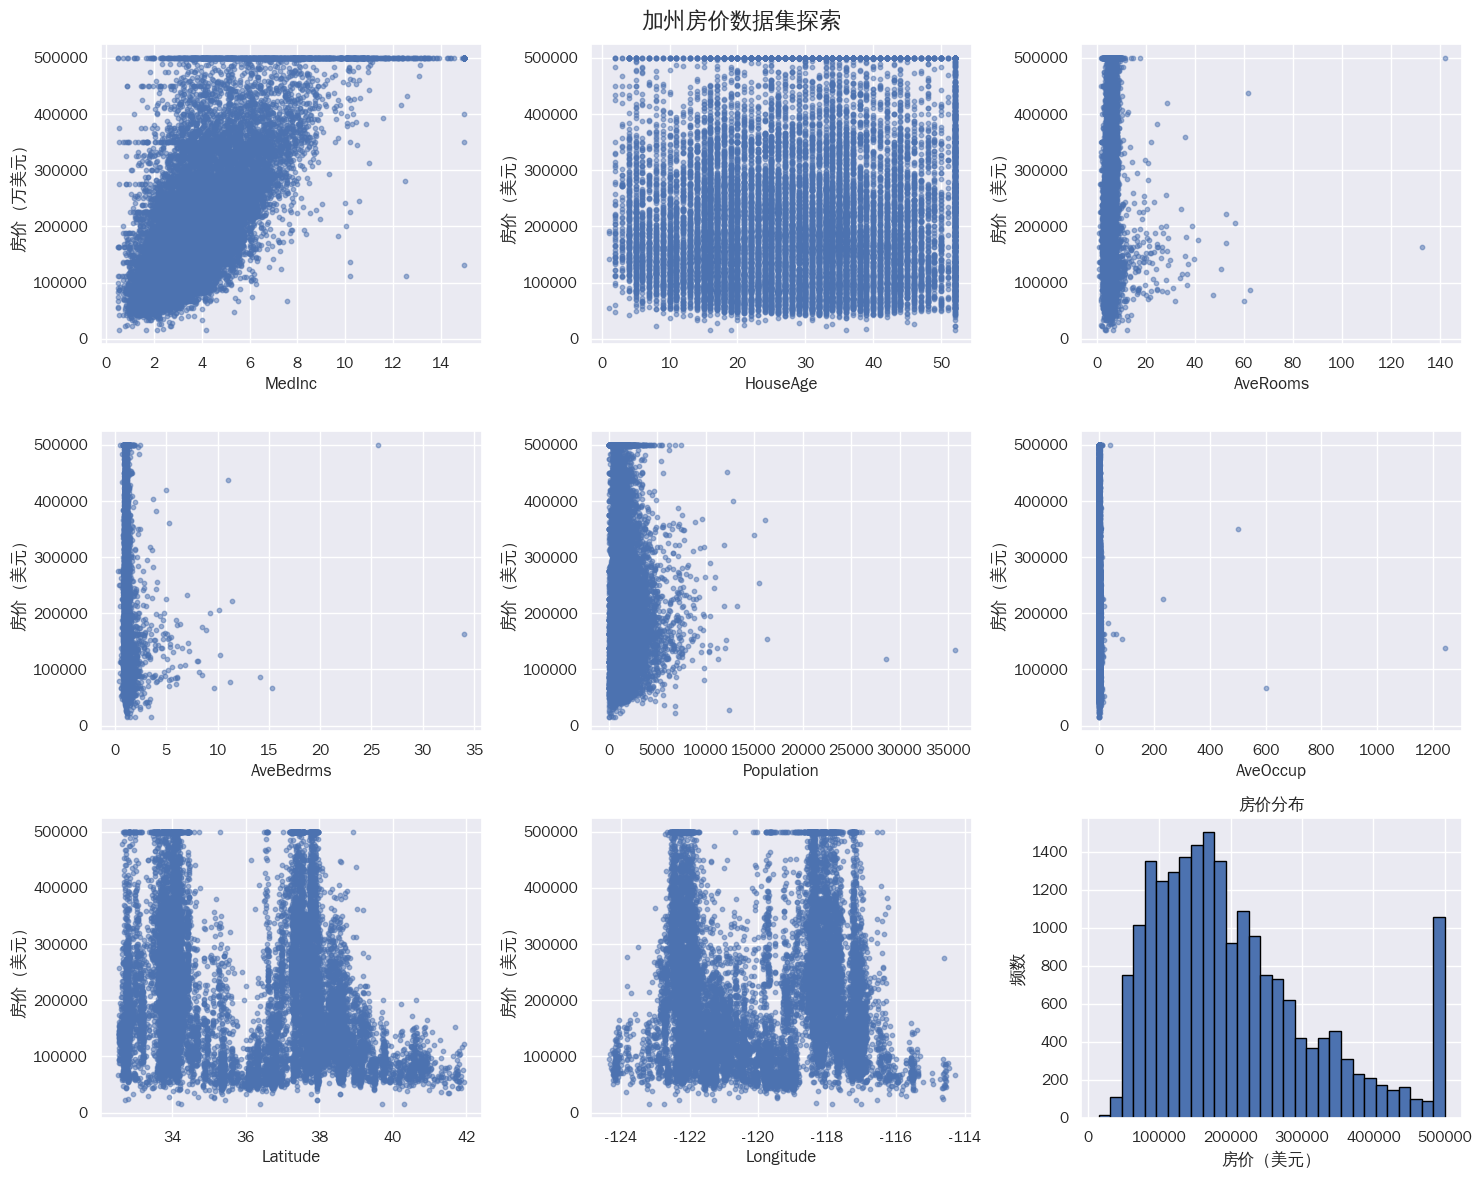

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(feature_names):
    ax = axes[i]
    ax.scatter(df[feature], df['房价'], alpha=0.5, s=10)
    ax.set_xlabel(feature)
    ax.set_ylabel('房价（美元）')
    if i == 0:
        ax.set_ylabel('房价（万美元）')

ax = axes[-1]
ax.hist(df['房价'], bins=30, edgecolor='black')
ax.set_xlabel('房价（美元）')
ax.set_ylabel('频数')
ax.set_title('房价分布')

plt.suptitle('加州房价数据集探索', fontsize=16)
plt.tight_layout()
plt.show()

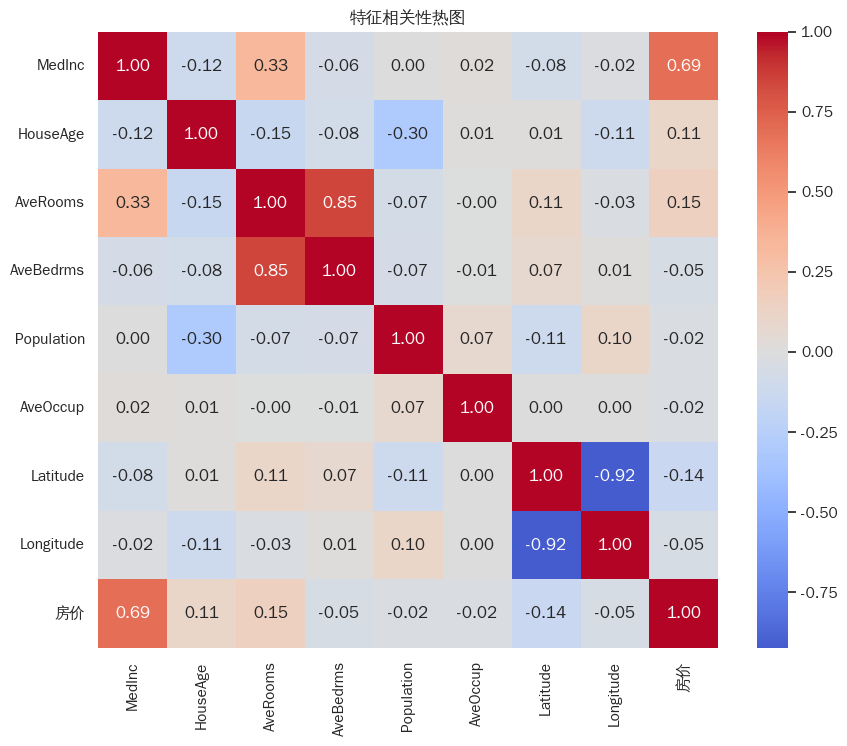

In [5]:
plt.figure(figsize=(10,8))
corr=df.corr()
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',center=0)
plt.title('特征相关性热图')
plt.show()

In [6]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42)

print(f"\n数据集划分：")
print(f"训练集：{x_train.shape[0]}个样本")
print(f"测试集：{x_test.shape[0]}个样本")

models = {
    '线性回归': LinearRegression(),
    '岭回归（Ridge）': Ridge(alpha=1.0),
    '套索回归（Lasso）': Lasso(alpha=0.1),
    '决策树': DecisionTreeRegressor(max_depth=5, random_state=42),
    '随机森林': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        '模型': name,
        'R²分数': r2,
        'RMSE': rmse,
        'MSE': mse
    })

    print(f"\n {name}:")
    print(f"R²分数：{r2:.4f}")
    print(f"RMSE：{rmse:.4f}(约 ${rmse*100000:,.0f})")
    print(f"MSE：{mse:.4f}")

results_df = pd.DataFrame(results)
print("\n模型性能对比")
print(results_df.sort_values('R²分数', ascending=False).to_string(index=False))


数据集划分：
训练集：16512个样本
测试集：4128个样本

 线性回归:
R²分数：0.5758
RMSE：0.7456(约 $74,558)
MSE：0.5559

 岭回归（Ridge）:
R²分数：0.5758
RMSE：0.7456(约 $74,555)
MSE：0.5559

 套索回归（Lasso）:
R²分数：0.4814
RMSE：0.8243(约 $82,435)
MSE：0.6796

 决策树:
R²分数：0.5997
RMSE：0.7242(约 $72,423)
MSE：0.5245

 随机森林:
R²分数：0.8050
RMSE：0.5055(约 $50,547)
MSE：0.2555

模型性能对比
         模型     R²分数     RMSE      MSE
       随机森林 0.805024 0.505468 0.255498
        决策树 0.599732 0.724234 0.524515
 岭回归（Ridge） 0.575819 0.745554 0.555851
       线性回归 0.575788 0.745581 0.555892
套索回归（Lasso） 0.481420 0.824349 0.679552


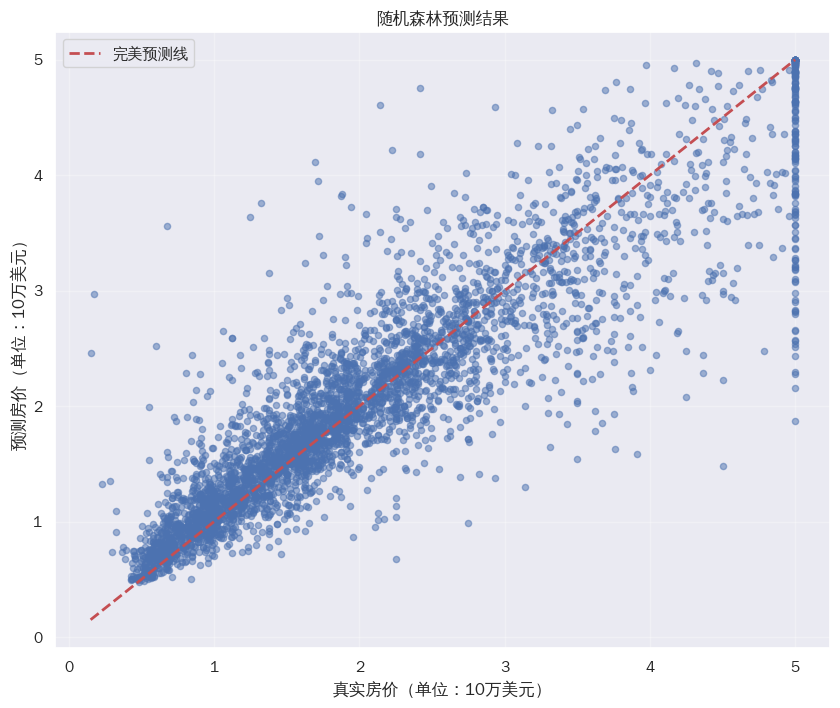

In [7]:
best_model=RandomForestRegressor()
best_model.fit(x_train,y_train)
y_pred_best=best_model.predict(x_test)

plt.figure(figsize=(10,8))
plt.scatter(y_test,y_pred_best,alpha=0.5,s=20)
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         'r--',lw=2,label='完美预测线')
plt.xlabel('真实房价（单位：10万美元）')
plt.ylabel('预测房价（单位：10万美元）')
plt.title('随机森林预测结果')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()


 随机森林决策特征重要性：
        特征      重要性
    MedInc 0.524641
  AveOccup 0.138216
 Longitude 0.090021
  Latitude 0.089713
  HouseAge 0.054434
  AveRooms 0.043192
Population 0.030412
 AveBedrms 0.029370


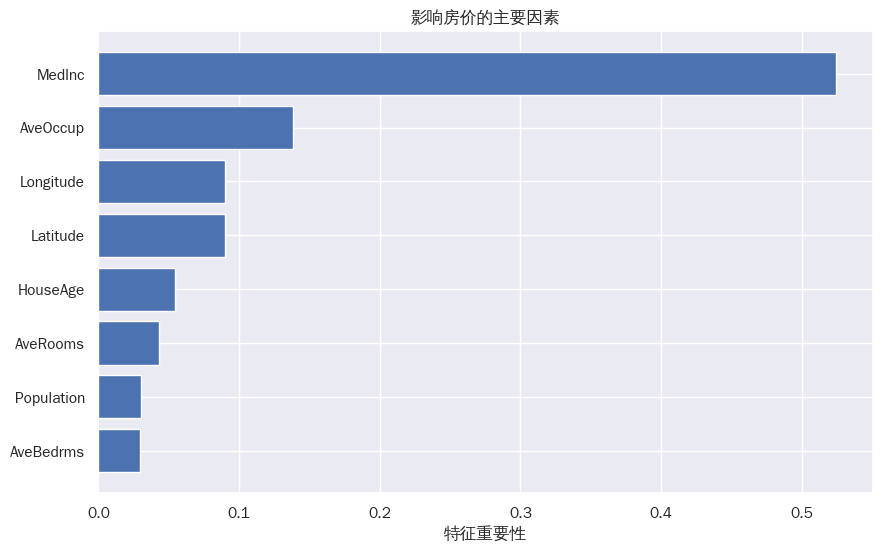

In [8]:
if hasattr(best_model,'feature_importances_'):
    importance_df=pd.DataFrame({
        '特征':feature_names,
        '重要性':best_model.feature_importances_
    }).sort_values('重要性',ascending=False)
    print("\n 随机森林决策特征重要性：")
    print(importance_df.to_string(index=False))

    plt.figure(figsize=(10,6))
    plt.barh(importance_df['特征'],importance_df['重要性'])
    plt.xlabel('特征重要性')
    plt.title('影响房价的主要因素')
    plt.gca().invert_yaxis()
    plt.show()

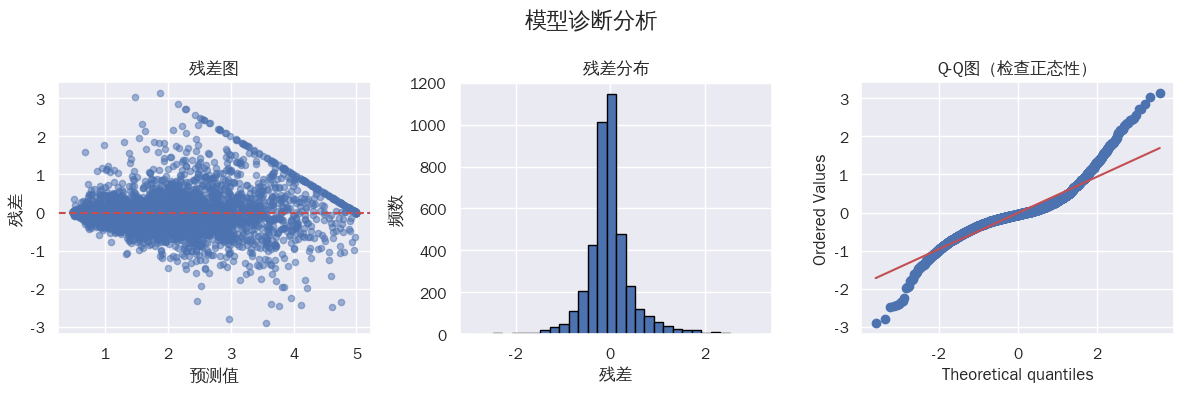

In [9]:
residuals=y_test-y_pred_best
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(y_pred_best,residuals,alpha=0.5,s=20)
plt.axhline(y=0,color='r',linestyle='--')
plt.xlabel('预测值')
plt.ylabel('残差')
plt.title('残差图')

plt.subplot(1,3,2)
plt.hist(residuals,bins=30,edgecolor='black')
plt.xlabel('残差')
plt.ylabel('频数')
plt.title('残差分布')

plt.subplot(1,3,3)
from scipy import stats
stats.probplot(residuals,dist='norm',plot=plt)
plt.title('Q-Q图（检查正态性）')

plt.suptitle('模型诊断分析',fontsize=16)
plt.tight_layout()
plt.show()

In [12]:
import joblib

joblib.dump(best_model,'../models/california_model.pkl')
joblib.dump(scaler,'../models/california_scaler.pkl')
print('模型和标准器已经保存')

模型和标准器已经保存
